In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Single Numerical Column


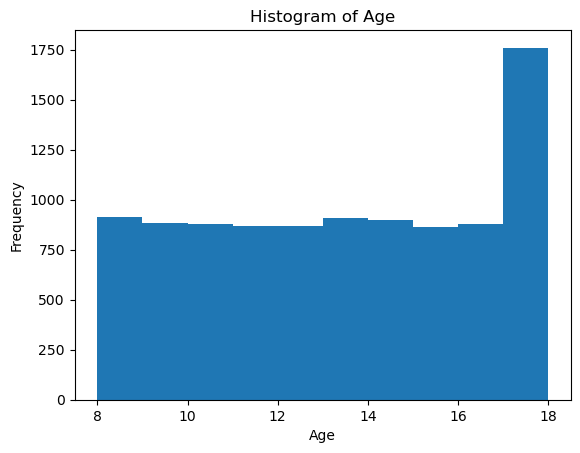

In [2]:
print("Single Numerical Column")
df=pd.read_csv("C:\\Users\\meena\\Downloads\\Indian_Kids_Screen_Time.csv")
plt.figure()
plt.hist(df['Age'], bins=10)
plt.title('Histogram of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

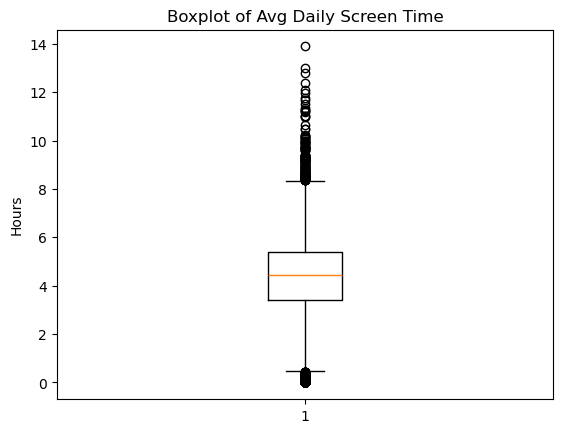

In [3]:
plt.figure()
plt.boxplot(df['Avg_Daily_Screen_Time_hr'])
plt.title('Boxplot of Avg Daily Screen Time')
plt.ylabel('Hours')
plt.show()

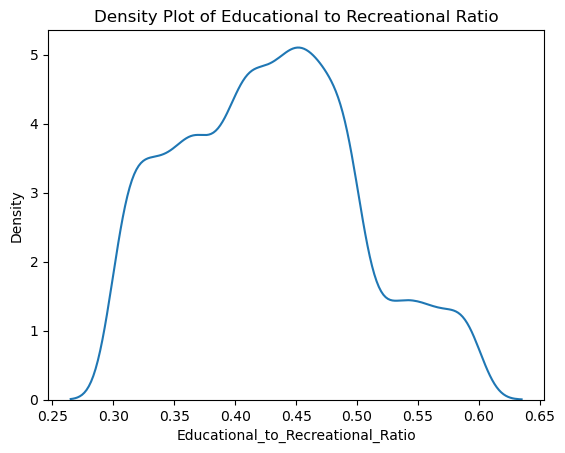

In [4]:
plt.figure()
sns.kdeplot(df['Educational_to_Recreational_Ratio'])
plt.title('Density Plot of Educational to Recreational Ratio')
plt.show()

Single Categorical Column


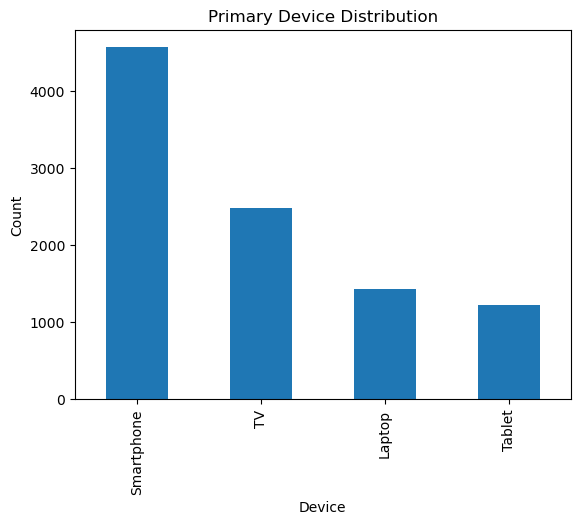

In [3]:
print("Single Categorical Column")
plt.figure()
df['Primary_Device'].value_counts().plot(kind='bar')
plt.title('Primary Device Distribution')
plt.xlabel('Device')
plt.ylabel('Count')
plt.show()

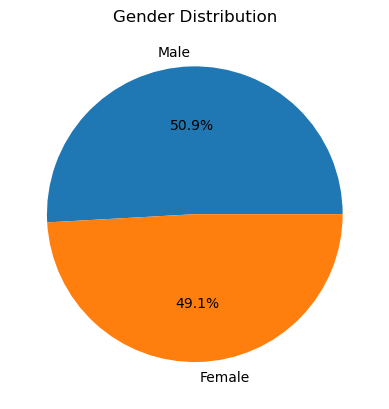

In [7]:
plt.figure()
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Gender Distribution')
plt.show()

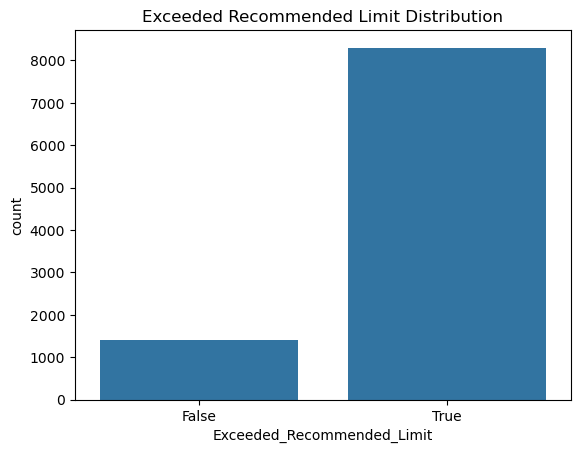

In [8]:
plt.figure()
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title('Exceeded Recommended Limit Distribution')
plt.show()

Numerical vs Numerical


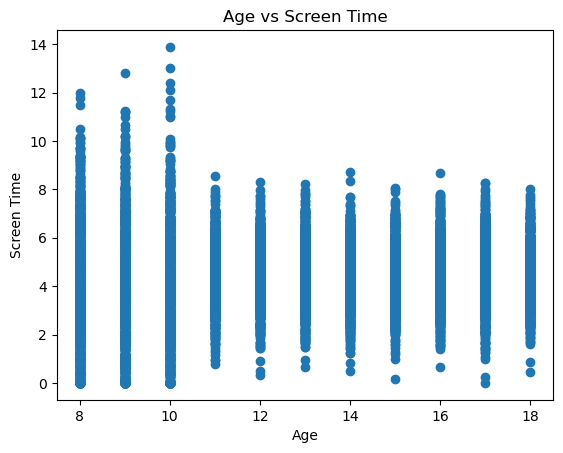

In [4]:
print("Numerical vs Numerical")
plt.figure()
plt.scatter(df['Age'], df['Avg_Daily_Screen_Time_hr'])
plt.xlabel('Age')
plt.ylabel('Screen Time')
plt.title('Age vs Screen Time')
plt.show()

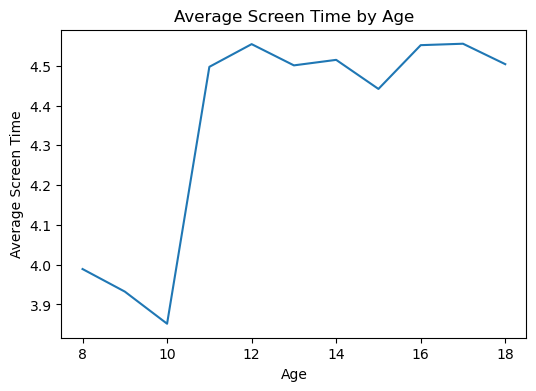

In [13]:
age_avg = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()
plt.figure(figsize=(6,4))
plt.plot(age_avg.index, age_avg.values)
plt.title('Average Screen Time by Age')
plt.xlabel('Age')
plt.ylabel('Average Screen Time')
plt.show()

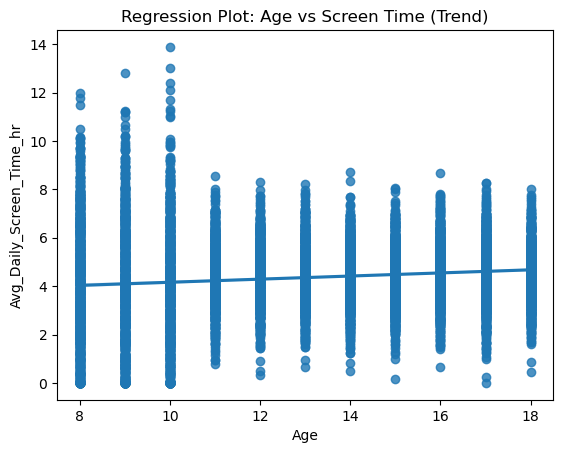

In [14]:
plt.figure()
sns.regplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title('Regression Plot: Age vs Screen Time (Trend)')
plt.show()

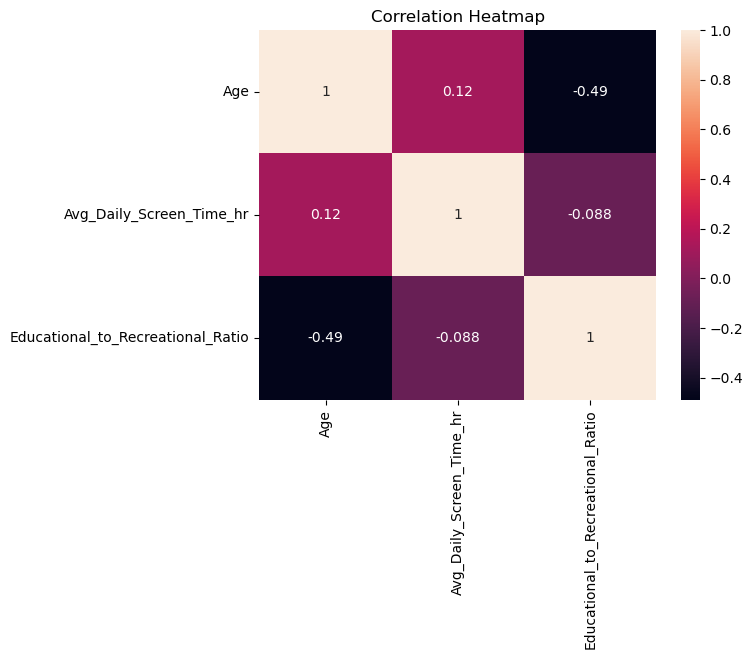

In [12]:
plt.figure()
sns.heatmap(df[['Age',
                'Avg_Daily_Screen_Time_hr',
                'Educational_to_Recreational_Ratio']].corr(),
            annot=True)
plt.title('Correlation Heatmap')
plt.show()

Numerical vs Categorical


<Figure size 640x480 with 0 Axes>

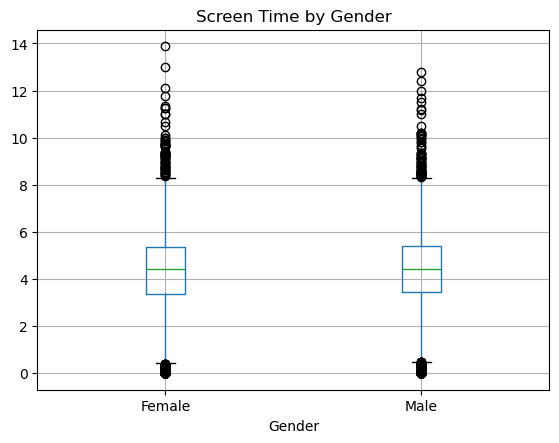

In [5]:
print("Numerical vs Categorical")
plt.figure()
df.boxplot(column='Avg_Daily_Screen_Time_hr', by='Gender')
plt.suptitle('')
plt.title('Screen Time by Gender')
plt.show()

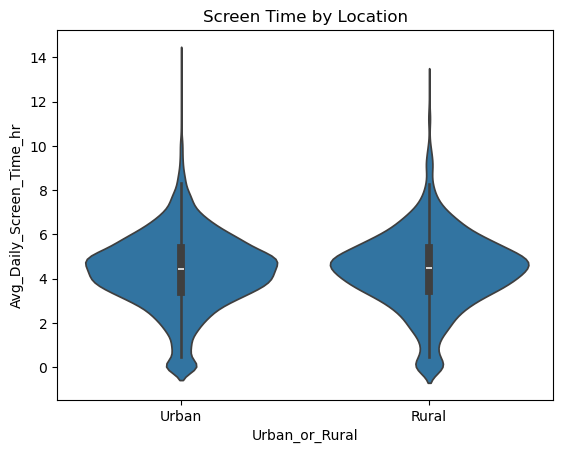

In [14]:
plt.figure()
sns.violinplot(x='Urban_or_Rural',
               y='Avg_Daily_Screen_Time_hr',
               data=df)
plt.title('Screen Time by Location')
plt.show()

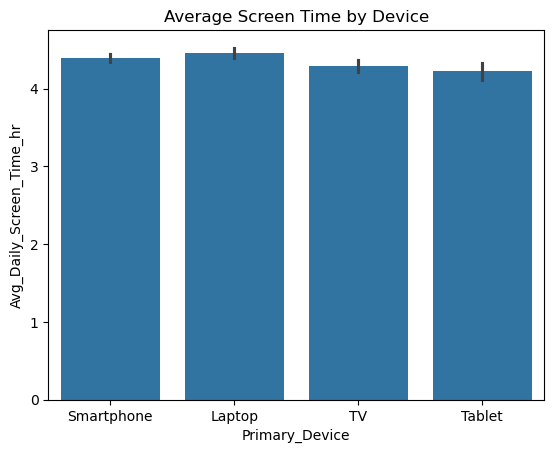

In [15]:
plt.figure()
sns.barplot(x='Primary_Device',
            y='Avg_Daily_Screen_Time_hr',
            data=df)
plt.title('Average Screen Time by Device')
plt.show()

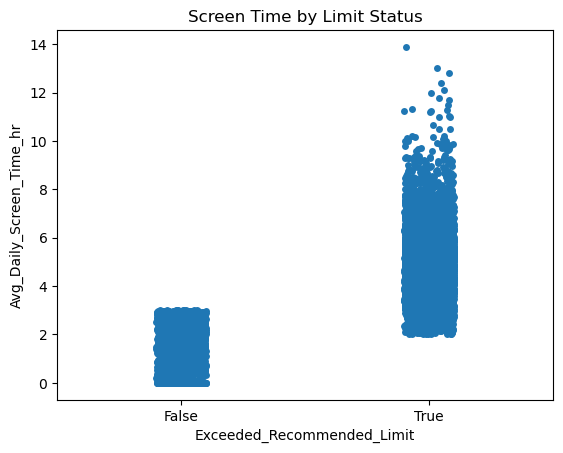

In [16]:
plt.figure()
sns.stripplot(x='Exceeded_Recommended_Limit',
              y='Avg_Daily_Screen_Time_hr',
              data=df)
plt.title('Screen Time by Limit Status')
plt.show()

Categorical vs Categorical


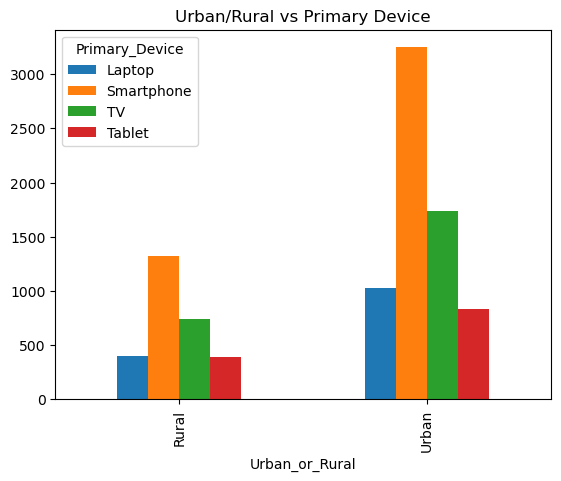

In [6]:
print("Categorical vs Categorical")
pd.crosstab(df['Urban_or_Rural'],
            df['Primary_Device']).plot(kind='bar')

plt.title('Urban/Rural vs Primary Device')
plt.show()

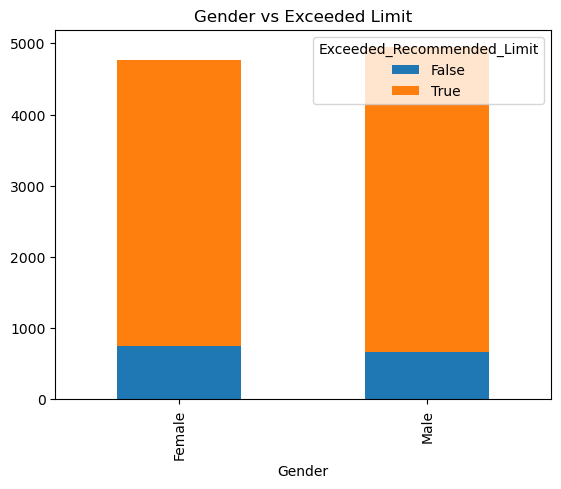

In [18]:
pd.crosstab(df['Gender'],
            df['Exceeded_Recommended_Limit']).plot(kind='bar', stacked=True)

plt.title('Gender vs Exceeded Limit')
plt.show()

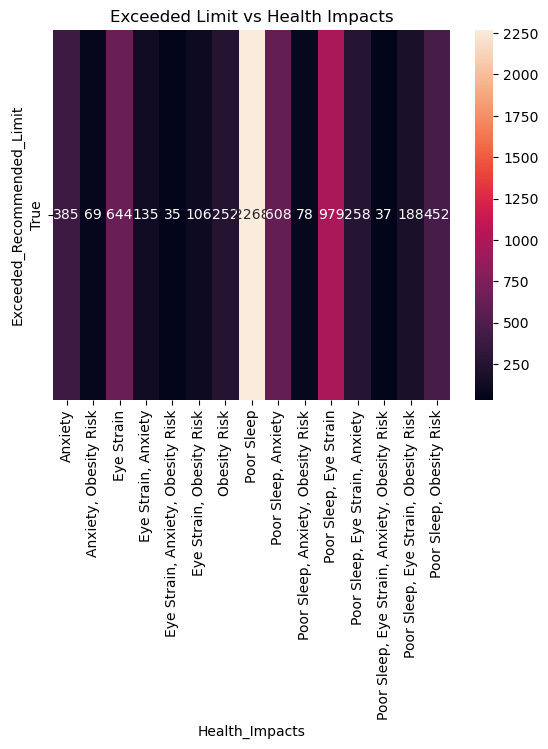

In [19]:
plt.figure()
sns.heatmap(pd.crosstab(df['Exceeded_Recommended_Limit'],
                        df['Health_Impacts']),
            annot=True,
            fmt='d')

plt.title('Exceeded Limit vs Health Impacts')
plt.show()

In [17]:
import matplotlib.pyplot as plt

def donut_chart(column_name,title):
    counts = df[column_name].value_counts()
    
    plt.figure()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    
    plt.title(title)
    plt.show()

Categorical vs Categorical


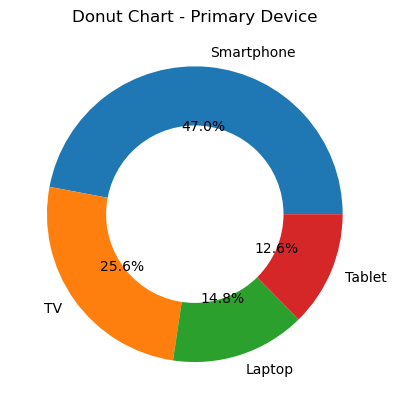

In [18]:
print("Categorical vs Categorical")
donut_chart('Primary_Device', 'Donut Chart - Primary Device')

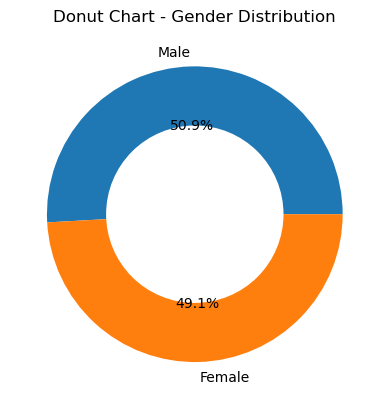

In [24]:
donut_chart('Gender', 'Donut Chart - Gender Distribution')

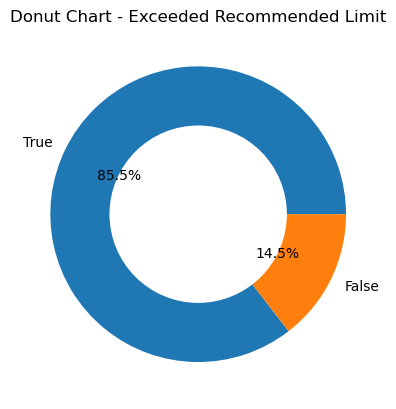

In [25]:
donut_chart('Exceeded_Recommended_Limit', 
            'Donut Chart - Exceeded Recommended Limit')

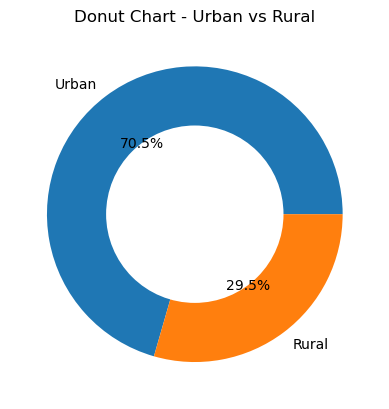

In [26]:
donut_chart('Urban_or_Rural', 
            'Donut Chart - Urban vs Rural')

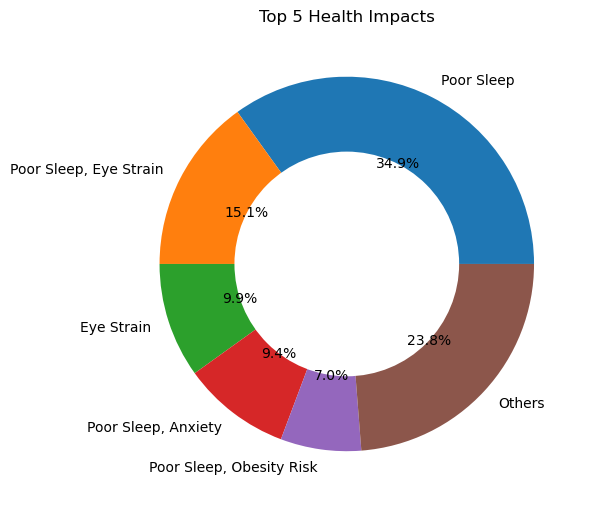

In [7]:
import matplotlib.pyplot as plt
def donut_chart_top5(column_name, title):
    counts = df[column_name].value_counts()
    top5 = counts.head(5)
    others = counts.iloc[5:].sum()
    if others > 0:
        top5['Others'] = others
    plt.figure(figsize=(6,6))
    plt.pie(top5, labels=top5.index, autopct='%1.1f%%')
    centre_circle = plt.Circle((0, 0), 0.60, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.title(title)
    plt.tight_layout()
    plt.show()
donut_chart_top5('Health_Impacts', 'Top 5 Health Impacts')

In [10]:
from statsmodels.graphics.mosaicplot import mosaic
!pip install statsmodels

Categorical vs Categorical


<Figure size 640x480 with 0 Axes>

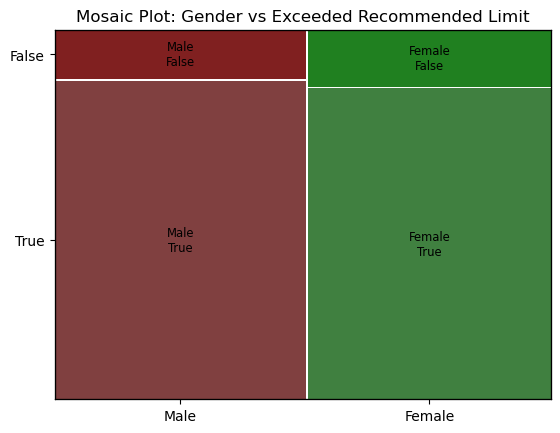

In [15]:
print("Categorical vs Categorical")
plt.figure()
mosaic(df, ['Gender', 'Exceeded_Recommended_Limit'])
plt.title('Mosaic Plot: Gender vs Exceeded Recommended Limit')
plt.show()

<Figure size 640x480 with 0 Axes>

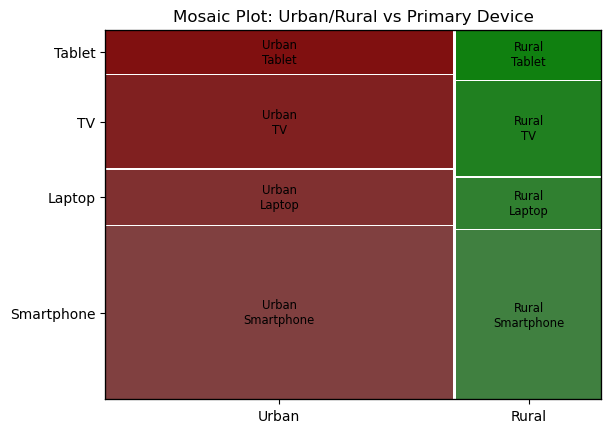

In [30]:
plt.figure()
mosaic(df, ['Urban_or_Rural', 'Primary_Device'])
plt.title('Mosaic Plot: Urban/Rural vs Primary Device')
plt.show()

In [8]:
df['Has_Poor_Sleep'] = df['Health_Impacts'].str.contains('Poor Sleep', case=False, na=False)
df['Has_Eye_Strain'] = df['Health_Impacts'].str.contains('Eye Strain', case=False, na=False)
df['Has_Anxiety'] = df['Health_Impacts'].str.contains('Anxiety', case=False, na=False)
df['Has_Obesity_Risk'] = df['Health_Impacts'].str.contains('Obesity Risk', case=False, na=False)

<Figure size 640x480 with 0 Axes>

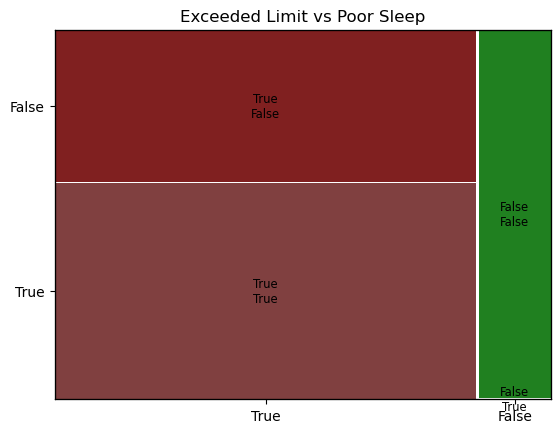

In [11]:
plt.figure()
mosaic(df, ['Exceeded_Recommended_Limit', 'Has_Poor_Sleep'])
plt.title('Exceeded Limit vs Poor Sleep')
plt.show()